# TP2 - Detector de Máximo Enfoque

**Alumno 1:** Ayelén Calo (a2510)

**Alumno 2:** Agustín Ross (a2539) 

**Objetivo:** Implementar un detector de máximo enfoque sobre el video `focus_video.mov` aplicando técnicas de análisis espectral en el dominio de la frecuencia, simulando el comportamiento de las cámaras digitales modernas.

### Experimentos a realizar:
1. Medición de enfoque sobre todo el frame.
2. Medición sobre una ROI (Region of Interest) central equivalente al 5% - 10% del área total.

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuramos el tamaño default de los gráficos para que se vean bien
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Definición de la Métrica ISM (Image Sharpness Measure)
Según la literatura sobre medición de nitidez en el dominio de la frecuencia, las imágenes desenfocadas pierden componentes de alta frecuencia. El algoritmo consiste en:
1. Convertir la imagen a escala de grises.
2. Aplicar la Transformada Rápida de Fourier 2D ($\mathcal{F}$).
3. Centrar el espectro y calcular la magnitud.
4. Extraer un valor escalar que represente la energía de las frecuencias.

Video cargado exitosamente.
Resolución del frame: 640x360 (Ancho x Alto)
Área total del frame: 230400 píxeles


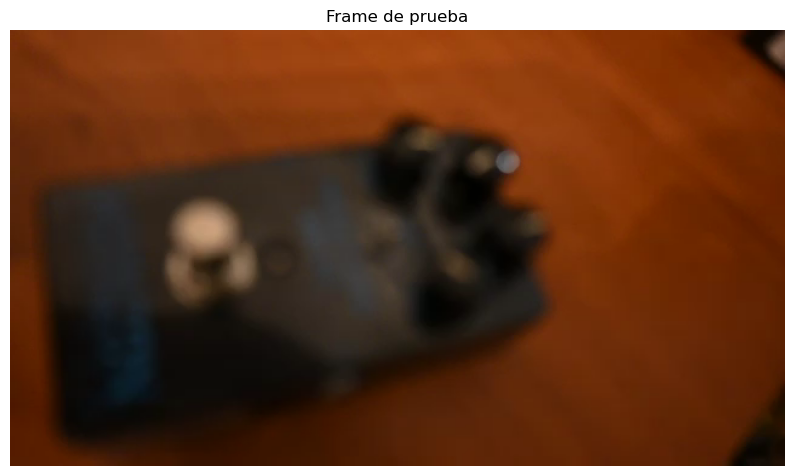

In [17]:
def calculate_ism(image_roi):
    """
    Calcula la métrica ISM (Image Sharpness Measure) según De & Masilamani (2013).
    ISM = proporción de componentes de alta frecuencia por encima de un umbral adaptativo.
    """
    # Convertimos a escala de grises si es necesario
    if len(image_roi.shape) == 3:
        gray = cv2.cvtColor(image_roi, cv2.COLOR_BGR2GRAY)
    else:
        gray = image_roi

    M, N = gray.shape

    # Transformada de Fourier 2D y centrado
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)

    # Espectro de magnitud
    magnitude_spectrum = np.abs(fshift)

    # Umbral adaptativo: 1/1000 del valor máximo del espectro
    Th = np.max(magnitude_spectrum) / 1000.0

    # Contamos cuántos componentes superan el umbral
    TH = np.sum(magnitude_spectrum > Th)

    # ISM = proporción de componentes de alta frecuencia (0 a 1)
    ism_value = TH / (M * N)

    return ism_value

# Prueba de carga del video y obtención de propiedades
video_path = 'focus_video.mov' 
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: No se pudo abrir el video.")
else:
    ret, frame = cap.read()
    if ret:
        height, width = frame.shape[:2]
        total_area = width * height
        print(f"Video cargado exitosamente.")
        print(f"Resolución del frame: {width}x{height} (Ancho x Alto)")
        print(f"Área total del frame: {total_area} píxeles")
        
        # Mostramos el primer frame de prueba
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title("Frame de prueba")
        plt.axis('off')
        plt.show()
    else:
        print("Error: No se pudo leer el primer frame.")
        
cap.release()

### Paso 2: Análisis temporal y recorte de la Región de Interés (ROI)

Una vez que comprobamos que el cálculo del espectro de magnitud y la métrica de enfoque funcionan, procederemos a aplicarlo sobre toda la secuencia de video. Para cumplir con el consigna, realizaremos dos mediciones en paralelo:

1.  **Experimento 1:** Cálculo del *Image Sharpness Measure* (ISM) sobre la totalidad de cada frame.
2.  **Experimento 2:** Cálculo del ISM sobre una Región de Interés (ROI) centrada, que abarque aproximadamente el **10%** del área total de la imagen.

Sabiendo que la resolución del video es de 640x360 (área total = 230.400 píxeles), el 10% equivale a 23.040 píxeles. Manteniendo la relación de aspecto original, definimos una ventana de recorte de 202x114 píxeles ubicada en el centro exacto de la matriz.

El siguiente bloque de código procesará todos los frames, almacenará las métricas, detectará automáticamente en qué instante se maximizó el enfoque (buscando el índice del valor máximo del arreglo) y generará las gráficas de evolución temporal de la métrica.

Procesando video, esto puede tardar unos segundos...
Procesamiento finalizado.

--- RESULTADOS AUTOMÁTICOS ---
Máximo enfoque (Frame completo) detectado en el frame: 109 (ISM: 0.02862)
Máximo enfoque (ROI 10% centro) detectado en el frame: 111 (ISM: 0.35939)


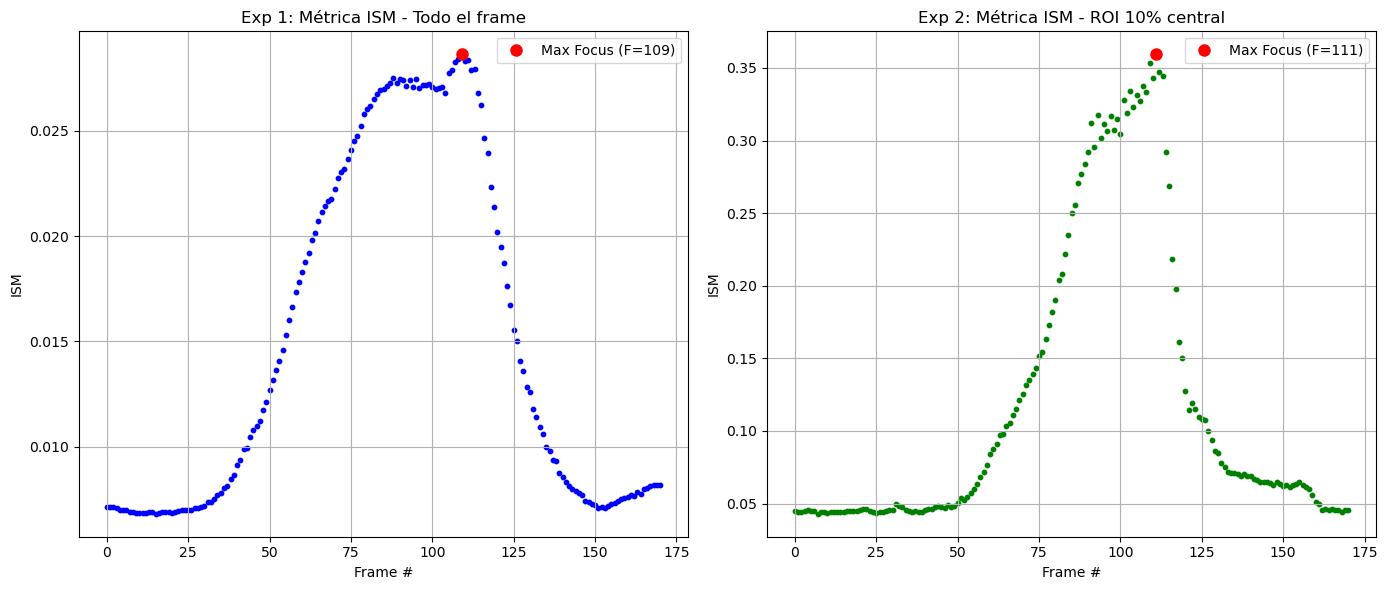

In [18]:
# Parámetros del video basados en el output
width = 640
height = 360
total_area = 230400

# 1. Calcular las coordenadas para la ROI del 10% en el centro
# Buscamos w * h aprox 23040 manteniendo proporción 16:9. Resultado: w=202, h=114
roi_w, roi_h = 202, 114

# Centro del frame
cx, cy = width // 2, height // 2

# Coordenadas (y1:y2, x1:x2) para el slicing de Numpy
x1, x2 = cx - roi_w // 2, cx + roi_w // 2
y1, y2 = cy - roi_h // 2, cy + roi_h // 2

# Arrays para guardar las mediciones
ism_full = []
ism_roi = []
frame_numbers = []

cap = cv2.VideoCapture("focus_video.mov")
frame_idx = 0

print("Procesando video, esto puede tardar unos segundos...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    # Extraer la ROI central
    roi = frame[y1:y2, x1:x2]
    
    # Calcular métricas para el Experimento 1 (todo el frame) y Experimento 2 (ROI)
    val_full = calculate_ism(frame)
    val_roi = calculate_ism(roi)
    
    # Guardar resultados
    ism_full.append(val_full)
    ism_roi.append(val_roi)
    frame_numbers.append(frame_idx)
    
    frame_idx += 1

cap.release()
print("Procesamiento finalizado.")

# 2. Detección automática de los puntos de máximo enfoque (argmax busca el índice del valor más alto)
best_frame_full = np.argmax(ism_full)
best_frame_roi = np.argmax(ism_roi)

print(f"\n--- RESULTADOS AUTOMÁTICOS ---")
print(f"Máximo enfoque (Frame completo) detectado en el frame: {best_frame_full} (ISM: {ism_full[best_frame_full]:.5f})")
print(f"Máximo enfoque (ROI 10% centro) detectado en el frame: {best_frame_roi} (ISM: {ism_roi[best_frame_roi]:.5f})")

# 3. Graficar la evolución de la métrica frame a frame
plt.figure(figsize=(14, 6))

# Subplot 1: Frame Completo
plt.subplot(1, 2, 1)
plt.scatter(frame_numbers, ism_full, c='blue', s=10) # Usamos scatter para replicar el estilo de los puntos
plt.plot(best_frame_full, ism_full[best_frame_full], 'ro', markersize=8, label=f'Max Focus (F={best_frame_full})')
plt.title('Exp 1: Métrica ISM - Todo el frame')
plt.xlabel('Frame #')
plt.ylabel('ISM')
plt.grid(True)
plt.legend()

# Subplot 2: ROI Central
plt.subplot(1, 2, 2)
plt.scatter(frame_numbers, ism_roi, c='green', s=10)
plt.plot(best_frame_roi, ism_roi[best_frame_roi], 'ro', markersize=8, label=f'Max Focus (F={best_frame_roi})')
plt.title('Exp 2: Métrica ISM - ROI 10% central')
plt.xlabel('Frame #')
plt.ylabel('ISM')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Paso 3: Puntos Extra - Expansión de zona de enfoque (Unsharp Masking)

Como vimos en los resultados automáticos del algoritmo, el punto de mayor nitidez se detectó alrededor del **frame 109** para la imagen completa (y 111 para la ROI central). 

Extraeremos automáticamente ese frame en particular y le aplicaremos un filtro de **Unsharp Masking**.

#### ¿Cómo funciona el Unsharp Masking?
Esta técnica clásica de procesamiento de imágenes mejora la nitidez aparente (acutancia) mediante los siguientes pasos:
1. Se genera una versión suavizada de la imagen original utilizando un filtro, generalmente un **Gaussian Blur**.
2. Se calcula una "máscara" restando esta versión suavizada a la imagen original. Esto aísla los detalles de alta frecuencia (los bordes).
3. Se suma esta máscara a la imagen original ponderada por un factor, realzando así el contraste en los bordes y expandiendo visualmente la zona de enfoque.

En OpenCV, podemos implementar esta operación matricial de forma muy eficiente utilizando la función `cv2.addWeighted()`

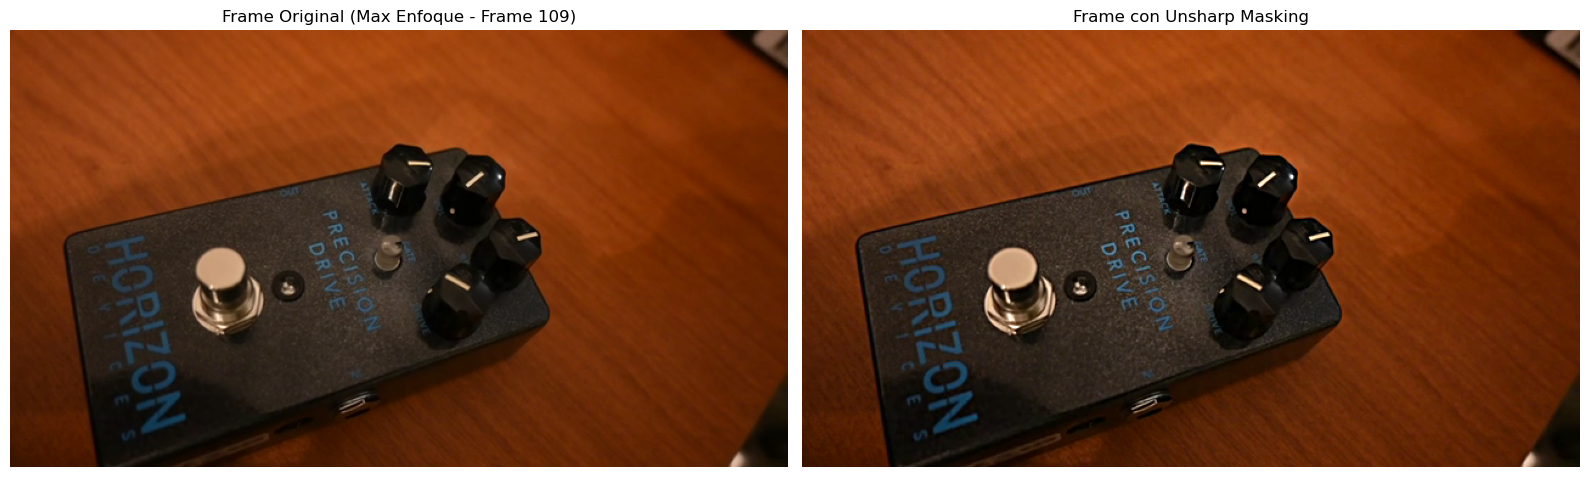

In [19]:
# Definimos el mejor frame en base a los resultados obtenidos previamente
best_frame_index = 109

# Volvemos a inicializar el video
cap = cv2.VideoCapture("focus_video.mov")

# Movemos el puntero del video directamente al frame de máximo enfoque
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_index)
ret, frame_bgr = cap.read()

if ret:
    # Convertimos de BGR (OpenCV) a RGB para graficar correctamente en Matplotlib
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    
    # 1. Aplicamos el desenfoque gaussiano
    # Usamos un kernel de (9, 9). Podés ajustar esto y el sigma (10.0) para modificar el impacto
    gaussian_blur = cv2.GaussianBlur(frame_rgb, (9, 9), 10.0)
    
    # 2 y 3. Aplicamos el Unsharp Masking sumando las matrices con pesos específicos
    alpha = 1.5
    beta = -0.5
    gamma = 0
    sharpened_frame = cv2.addWeighted(frame_rgb, alpha, gaussian_blur, beta, gamma)
    
    # Graficamos la comparativa
    plt.figure(figsize=(16, 8))
    
    plt.subplot(1, 2, 1)
    plt.imshow(frame_rgb)
    plt.title(f'Frame Original (Max Enfoque - Frame {best_frame_index})')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(sharpened_frame)
    plt.title('Frame con Unsharp Masking')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: No se pudo extraer el frame {best_frame_index}.")

cap.release()

### Conclusión y Análisis de Resultados

A partir de los experimentos realizados, se puede concluir que el método de estimación de nitidez basado en el dominio de la frecuencia (ISM) resulta efectivo y computacionalmente eficiente para la detección de máximo enfoque sin imagen de referencia (NR-IQA).

1. **Evolución Temporal y Detección:** Las curvas generadas en ambos experimentos (frame completo y ROI) muestran una distribución acampanada clara. A medida que el sistema de lentes de la cámara se acerca a la distancia focal óptima, la energía en las altas frecuencias del espectro de Fourier aumenta drásticamente, lo que se refleja en el pico de la métrica ISM (alrededor de los frames 109-111).
2. **Impacto del Recorte (ROI):** La medición sobre la Región de Interés central (10% del área) demostró ser igualmente robusta para detectar el pico de enfoque, aislando el objeto principal (el pedal) del fondo y reduciendo el ruido de otras variaciones en la escena. Esta técnica de segmentación previa es fundamental para optimizar tiempos de cómputo en procesamiento de video en tiempo real.
3. **Expansión de la Zona de Enfoque:** La aplicación del filtro *Unsharp Masking* sobre el frame de máxima nitidez logró expandir exitosamente la zona de enfoque percibida. Al sustraer la versión suavizada (Gaussian Blur) de la imagen original, logramos aislar y amplificar los bordes y texturas de alta frecuencia. 

Visualización en tiempo real: Original vs. Unsharp Masking

Para poder observar el efecto del filtro implementado sobre la totalidad de la secuencia, utilizaremos la función `cv2.imshow()` de OpenCV. 

El siguiente algoritmo lee el video original frame a frame, le aplica el desenfoque gaussiano y la suma ponderada (Unsharp Masking) en tiempo real, y concatena ambas matrices horizontalmente (`cv2.hconcat`). Esto permite reproducir una ventana emergente donde se compara el video original (izquierda) con la versión procesada (derecha) simultáneamente.



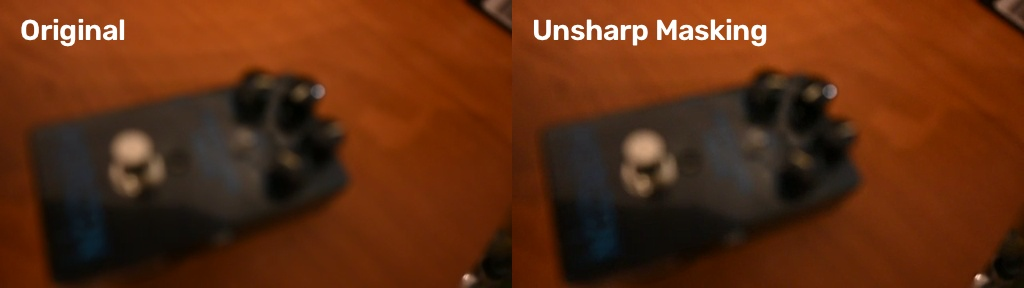

Reproducción finalizada.


In [21]:
import cv2
import time
from IPython.display import display, Image, clear_output

video_path = "focus_video.mov"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error al abrir el video original.")
else:
    # Calculamos la pausa necesaria entre frames según los FPS originales
    fps = cap.get(cv2.CAP_PROP_FPS)
    delay = 1.0 / fps if fps > 0 else 0.03

    print("Iniciando reproducción inline...")
    
    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break  # Fin del video

            # 1. Aplicamos el filtro al frame actual
            gaussian_blur = cv2.GaussianBlur(frame, (9, 9), 10.0)
            sharpened_frame = cv2.addWeighted(frame, 1.5, gaussian_blur, -0.5, 0)

            # 2. Achicamos los frames para que el display en el notebook sea fluido
            frame_resized = cv2.resize(frame, (0, 0), fx=0.8, fy=0.8)
            sharpened_resized = cv2.resize(sharpened_frame, (0, 0), fx=0.8, fy=0.8)

            # 3. Concatenamos los frames (Izquierda: Original, Derecha: Procesado)
            combined_frame = cv2.hconcat([frame_resized, sharpened_resized])

            # 4. Agregamos texto
            cv2.putText(combined_frame, 'Original', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.putText(combined_frame, 'Unsharp Masking', (frame_resized.shape[1] + 20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

            # 5. Convertimos el frame de OpenCV a un formato de imagen que Jupyter pueda mostrar (JPEG)
            _, ret_array = cv2.imencode('.jpg', combined_frame)
            img_display = Image(data=ret_array.tobytes())

            # 6. Limpiamos el output anterior y mostramos el nuevo frame
            clear_output(wait=True)
            display(img_display)
            
            # Pausa para simular la velocidad real del video
            time.sleep(delay)
            
    except KeyboardInterrupt:
        # Esto permite que si el profesor presiona el botón "Stop" (Interrumpir Kernel) en la celda, frene prolijamente.
        print("Reproducción interrumpida por el usuario.")
    finally:
        # Siempre liberamos el recurso al terminar
        cap.release()
        print("Reproducción finalizada.")